# PRiSM Example: German Credit Card Data

This notebook demonstrates the PRiSM (Partial Responses in Structured Models) method, which is designed to transform black-box classifiers into inherently interpretable models without compromising predictive performance. This approach is particularly valuable in high-stakes applications where understanding the model's decision-making process is crucial.

The method addresses a key challenge in machine learning: the trade-off between model complexity and interpretability. It allows us to create models that are both accurate and transparent. In this example, we'll use a German credit card dataset to illustrate the PRiSM method. While this isn't a medical dataset, the principles demonstrated here are directly applicable to clinical data and decision support systems.

Here, the target outcome we are modelling is "Class label", which refers to:

- 0: a customer who **did not default** on their loan
- 1: a customer who **did default** on their loan

We would like to use the available features to model the likelihood of a customer defaulting, and understand how each feature contributes to that likelihood.

## 1. Setup and Imports

First, we need to import the necessary libraries and set up our environment.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from prism.config import RAW_DATA_DIR, MODELS_DIR
from prism.preprocessing import normalize, feature_summary, plot_feature_histograms
from prism.maskedmlp import train_mlp_batched, train_maskedmlp
from prism.partial_responses import partial_responses
from prism.response_plot import plot_partial_responses
from prism.nomogram import nomogram, display_nomograms_side_by_side
from prism.lasso import lasso
from prism.device_tools import get_device, get_num_cpu_workers
from prism.metrics import evaluate_model_performance, compare_model_performance

2024-09-03 08:47:10.544 | INFO     | prism.config:<module>:11 - PROJ_ROOT path is: C:\Users\localuser\PRiSM\prism_github


In [2]:
%reload_ext autoreload

We set up our computational device (CPU or GPU if available) and set a random seed for reproducibility.

We'll use the 'lebesgue' method for partial responses, which is one of two methods (the other being 'dirac') for calculating partial responses. The Lebesgue method uses an average over the predicted surface, which can be more stable for some datasets, but more computationally intensive. If you're working with a bigger dataset, or low compute resources, starting with 'dirac' may be better.

In [3]:
# Set device to 'cpu', or GPU ('cuda' for NVIDIA, 'mps' for Apple Silicon)
# By default, we select the best available device
device = get_device() 
print(f"Using device: {device}")

# Set random seed for reproducibility
random_seed = 257
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# Set method and other parameters
partial_response_method  = 'lebesgue'
SAVE_METRICS = True

# TODO: setup model saving.
SAVE_MODELS = False 

Using device: cuda


For multithreading compute-intensive tasks, the recommended number of workers for GPU processing is 1, otherwise for CPU stick to the default (number of logical cores - 1). However, depending on your hardware, you may want to experiment.

In [4]:
if device != 'cpu':
    max_workers = 1
else:
    max_workers = get_num_cpu_workers()
print(f"max_workers = {max_workers}")

max_workers = 1


## 2. Load and Preprocess Data

Next, we load the German credit card data and perform necessary preprocessing steps.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

def preprocess_german_credit_data(data, target_column, feature_columns, test_size=0.2, random_state=257, shuffle=False, credit_scale=0.01):
    """
    Preprocess the German Credit Card dataset.

    Parameters:
    data (pd.DataFrame): The raw German Credit Card dataset
    target_column (str or int): The name or index of the target column
    feature_columns (list): List of column names or indices to use as features
    test_size (float): Proportion of the dataset to include in the test split
    random_state (int): Random state for reproducibility

    Returns:
    tuple: X_train, X_test, y_train, y_test (all as pd.DataFrame or pd.Series)
    """
    # Select features and target
    if isinstance(target_column, int):
        target_column = data.columns[target_column]
    
    if all(isinstance(col, int) for col in feature_columns):
        feature_columns = data.columns[feature_columns]
    
    X = data.copy()[feature_columns]
    y = data[target_column]

    # Scale the 'Credit amount' if it exists in the dataset
    if 'Credit amount' in data.columns:
        X['Credit amount'] = X['Credit amount'] * credit_scale
        X['Credit amount'] = X['Credit amount'].round()

    # Encode categorical variables
    label_encoder = LabelEncoder()
    for column in X.select_dtypes(include=['object']):
        X[column] = label_encoder.fit_transform(X[column].astype(str))

    # Impute missing values
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state=random_seed,shuffle=shuffle)

    # Ensure the target variable is binary
    y_train = (y_train == y_train.max()).astype(int)
    y_test = (y_test == y_test.max()).astype(int)

    return X_train, X_test, y_train, y_test

In [6]:
# Load data
german_credit_data = pd.read_csv(RAW_DATA_DIR.joinpath('GermanCC_attributes.csv'))

target_column = 'Class label'
feature_columns = [0, 1, 2, 4, 5, 6, 13, 19, 20, 21]  # List of column indices to use as features

X_train, X_test, y_train, y_test = preprocess_german_credit_data(
    german_credit_data, 
    target_column, 
    feature_columns,
    credit_scale=0.01,
    test_size=0.3, 
    random_state=random_seed
)

# Normalize the data to ensure all features have a median of zero
X_train_normalized, X_test_normalized = normalize(X_train, X_test)

# Convert to tensors for use with PyTorch
X_train_tensor = torch.tensor(X_train_normalized.values, dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(X_test_normalized.values, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32, device=device)

feature_names = [
    'Account Status',
    'Duration (Months)',
    'Credit History',
    'Credit Amount',
    'Savings/Bonds',
    'Employment Length',
    'Other Plans',
    'Foreign Worker',
    'Unknown1',
    'Unknown2'
]

## 3. Data Overview

Before building our models, we'll get an overview of the data.

In [7]:
print("Shape of training data:", X_train.shape)
print("Shape of testing data:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))

Shape of training data: (700, 10)
Shape of testing data: (300, 10)

Class distribution in training set:
Class label
0    0.704286
1    0.295714
Name: proportion, dtype: float64

Class distribution in test set:
Class label
0    0.69
1    0.31
Name: proportion, dtype: float64


In [8]:
feature_stats = feature_summary(X_train, categorical_threshold = 15)
print("Feature Statistics:")
print(feature_stats)

Feature Statistics:
                                    Data Type  Non-Null Count  Null Count  \
Status of existing checking account   float64             700           0   
Duration in month                     float64             700           0   
Credit history                        float64             700           0   
Credit amount                         float64             700           0   
Savings account/bonds                 float64             700           0   
Period of present employment          float64             700           0   
Other installment plans               float64             700           0   
Foreign worker                        float64             700           0   
Unknown1                              float64             700           0   
unknown2                              float64             700           0   

                                          Mean  Median    Std Dev    IQR  Min  \
Status of existing checking account   2.585714     

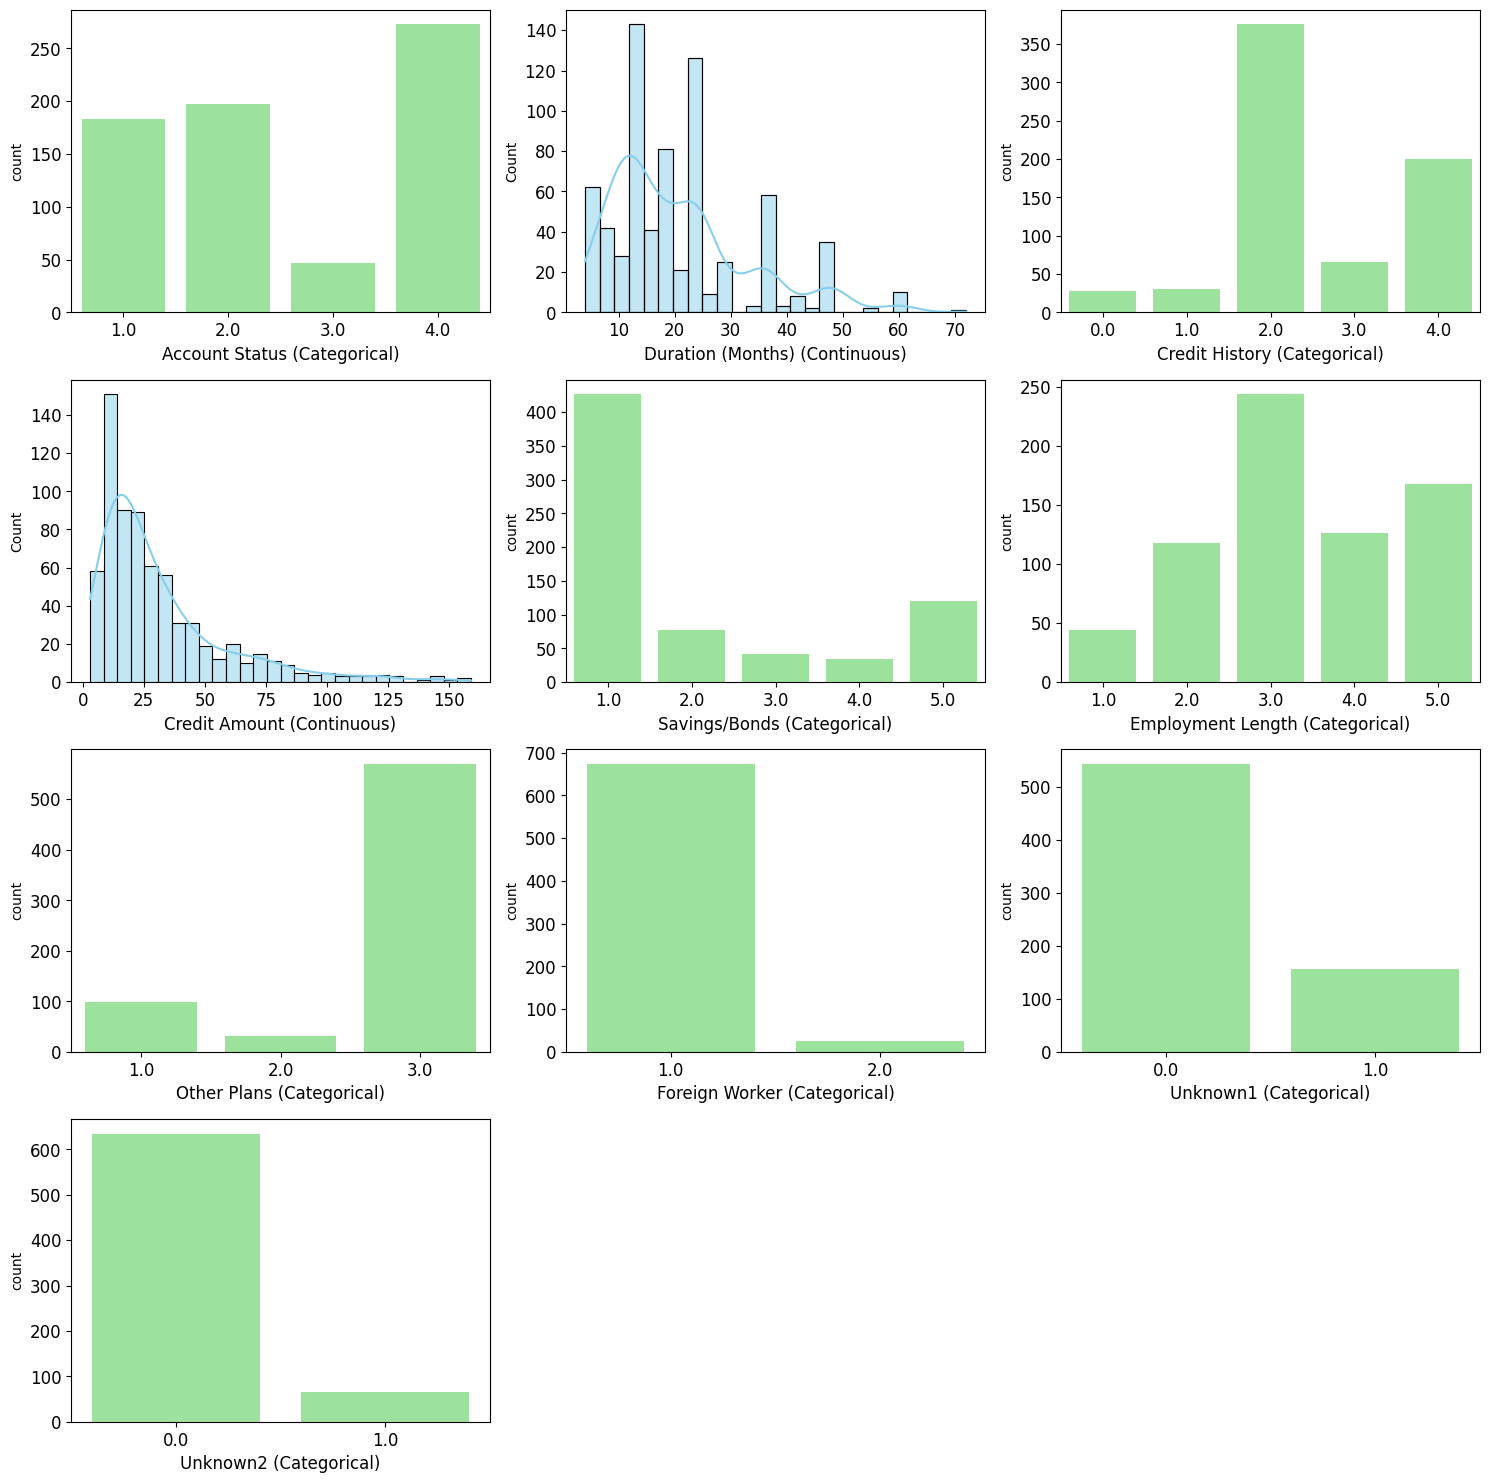

In [9]:
plot_feature_histograms(X_train, feature_stats,figsize=(15,15),feature_names=[*feature_names,'Class label']);

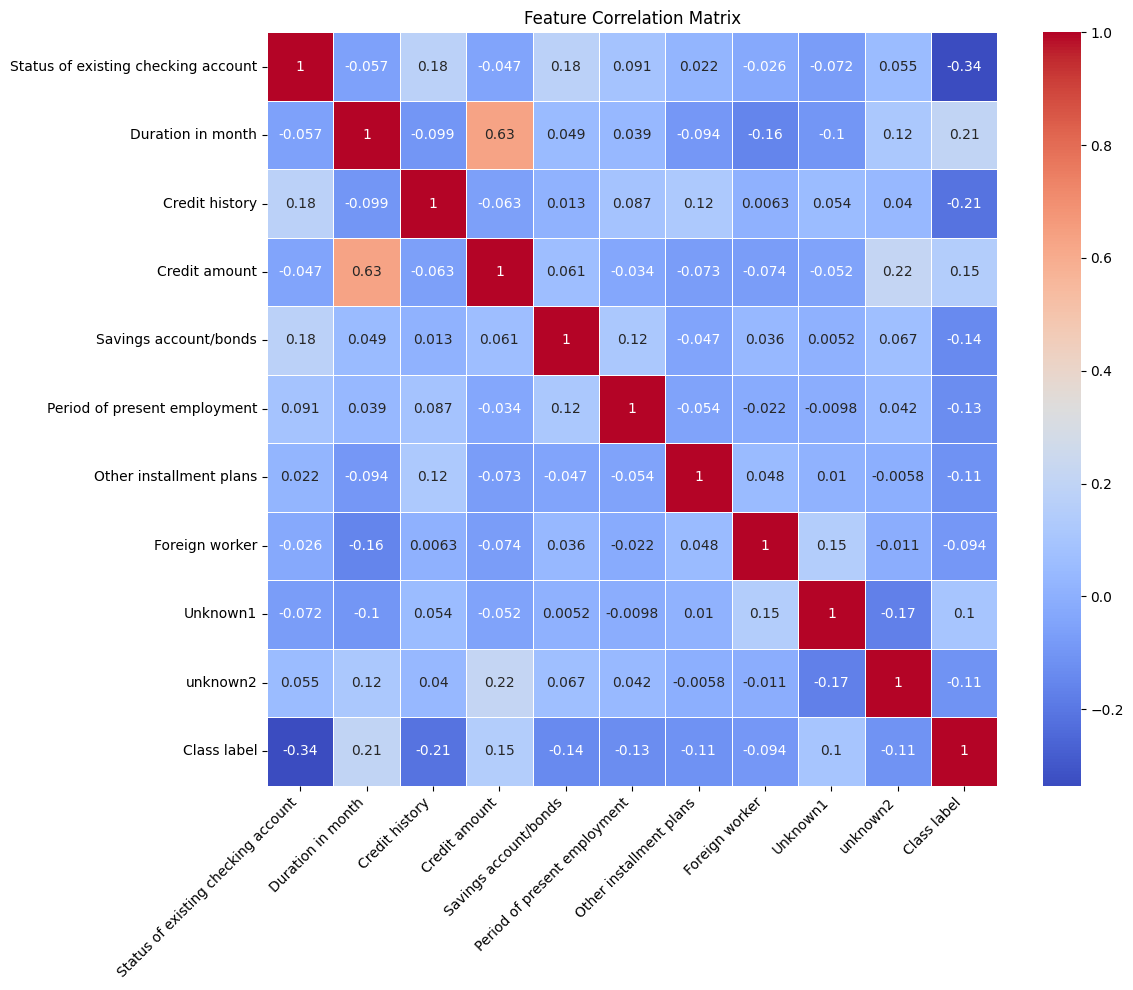

In [10]:
# Correlation matrix
correlation_matrix = pd.concat([X_train, y_train], axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Train Initial Black Box Model (MLP)

We start by training a black box model, in this case, a Multi-Layer Perceptron (MLP) with 10 nodes in the hidden layer. This model serves as our baseline and represents the type of hard-to-interpret model that is often used in machine learning.

In [11]:
mlp_hyperparameters = {
    'n_hidden': 10,
    'weight_decay': 0.0001,
    'lr': 0.001,
    'patience': 10,
    'tolerance': 0.00001,
    'batch_size': 32,
    'device': device,
    'seed': random_seed
}

blackbox_model = train_mlp_batched(X_train_normalized, y_train, X_test_normalized, y_test, **mlp_hyperparameters)

Epoch 0: Train loss 0.7623, Test loss 0.7541
Epoch 1: Train loss 0.7124, Test loss 0.7045
Epoch 2: Train loss 0.6719, Test loss 0.6644
Epoch 3: Train loss 0.6382, Test loss 0.6327
Epoch 4: Train loss 0.6130, Test loss 0.6061
Epoch 5: Train loss 0.5907, Test loss 0.5855
Epoch 6: Train loss 0.5744, Test loss 0.5692
Epoch 7: Train loss 0.5612, Test loss 0.5558
Epoch 8: Train loss 0.5499, Test loss 0.5451
Epoch 9: Train loss 0.5415, Test loss 0.5359
Epoch 10: Train loss 0.5342, Test loss 0.5282
Epoch 11: Train loss 0.5271, Test loss 0.5220
Epoch 12: Train loss 0.5226, Test loss 0.5164
Epoch 13: Train loss 0.5185, Test loss 0.5119
Epoch 14: Train loss 0.5133, Test loss 0.5073
Epoch 15: Train loss 0.5108, Test loss 0.5036
Epoch 16: Train loss 0.5062, Test loss 0.5005
Epoch 17: Train loss 0.5043, Test loss 0.4977
Epoch 18: Train loss 0.5014, Test loss 0.4953
Epoch 19: Train loss 0.4994, Test loss 0.4930
Epoch 20: Train loss 0.4980, Test loss 0.4913
Epoch 21: Train loss 0.4956, Test loss 0.489


---- Model Performance Metrics MLP - training data ----
Threshold (prevalence) set to: 0.296
AUROC:		0.818 (95% CI: 0.783-0.848) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.723 (Proportion of correct predictions)
Precision:	0.522 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.754 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.617 (Harmonic mean of precision and recall)
--------------------------------------------


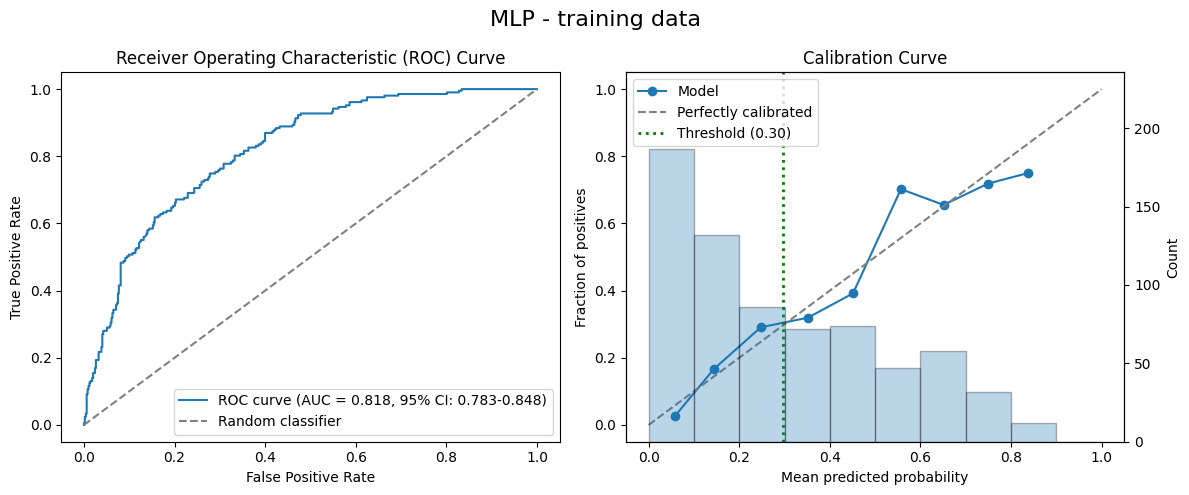


---- Model Performance Metrics MLP - test data ----
Threshold (prevalence) set to: 0.296
AUROC:		0.808 (95% CI: 0.753-0.859) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.723 (Proportion of correct predictions)
Precision:	0.540 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.720 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.618 (Harmonic mean of precision and recall)
--------------------------------------------


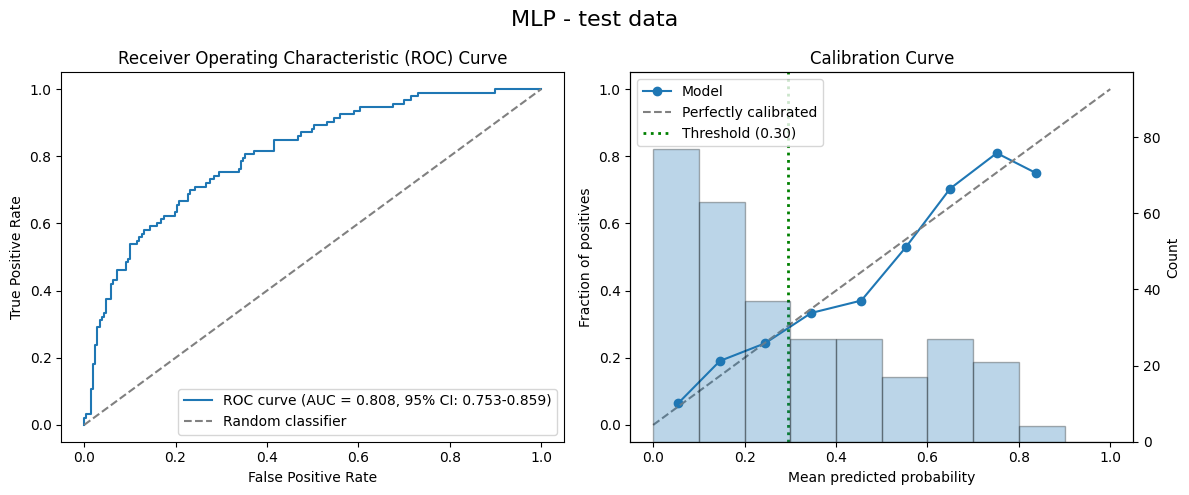

In [12]:
y_pred_train_blackbox = blackbox_model.predict(X_train_tensor)
y_pred_test_blackbox = blackbox_model.predict(X_test_tensor)

# Evaluate MLP
results_mlp_train = evaluate_model_performance(y_train, y_pred_train_blackbox, y_train, title="MLP - training data")
results_mlp_test = evaluate_model_performance(y_test, y_pred_test_blackbox, y_train, title="MLP - test data")

## 5. Calculate Partial Responses

Now we calculate partial responses for our black box model. This is a key step in the PRiSM method. Partial responses help us understand how individual features or pairs of features contribute to the model's predictions, making the black box model more interpretable.

In [13]:
partial_responses_params = {
    'x_train': X_train_tensor,
    'method': partial_response_method,
    'device': device,
    'batch_size': 512,
    'max_workers': max_workers
}

partial_responses_train = partial_responses(X_train_tensor, blackbox_model, **partial_responses_params)
partial_responses_test = partial_responses(X_test_tensor, blackbox_model, **partial_responses_params)

Main compute device: cuda
Max threads: 1
Batch size: 512
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Bivariate 3,9,	(cuda)
Bivariate 4,5,	(cuda)
Bivariate 4,6,	(cuda)
Bivariate 4,7,	(cuda)
Bivaria

## 6. Perform LASSO on Partial Responses

We use LASSO (Least Absolute Shrinkage and Selection Operator) to select the most consequential partial responses. This step helps us identify which features or feature interactions contribute most to the model's predictions. A range of regularization strengths (lambda) are used, and for each one a logistic regression model with LASSO regularization is trained and evaluated. Based on the results, we can choose the most suitable lambda, balancing model performance against the total number of selected features.

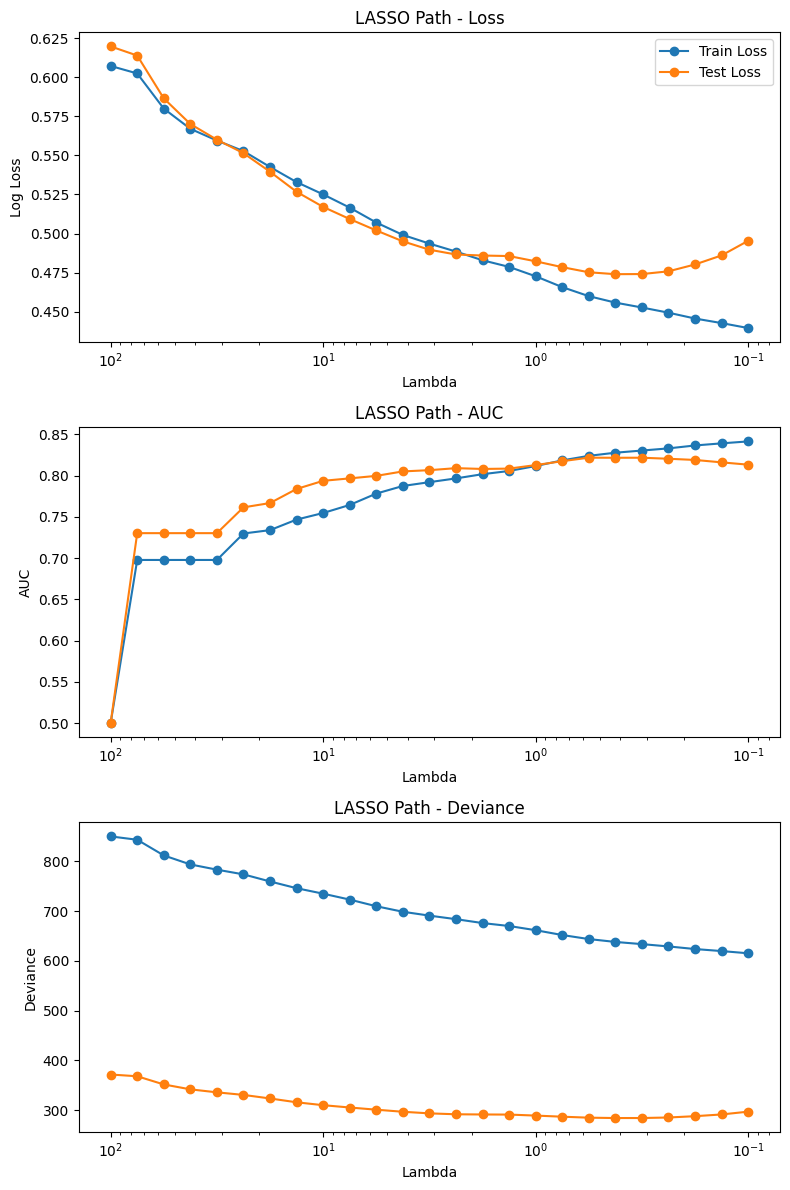

All fits converged successfully.


In [14]:
lasso_results = lasso(
    partial_responses_train, 
    partial_responses_test, 
    y_train, 
    y_test, 
    feature_names=feature_names,
    nlambda=25, 
    min_lambda=0.1,
    max_lambda=100,
    batch_size=2,
    seed=random_seed
)

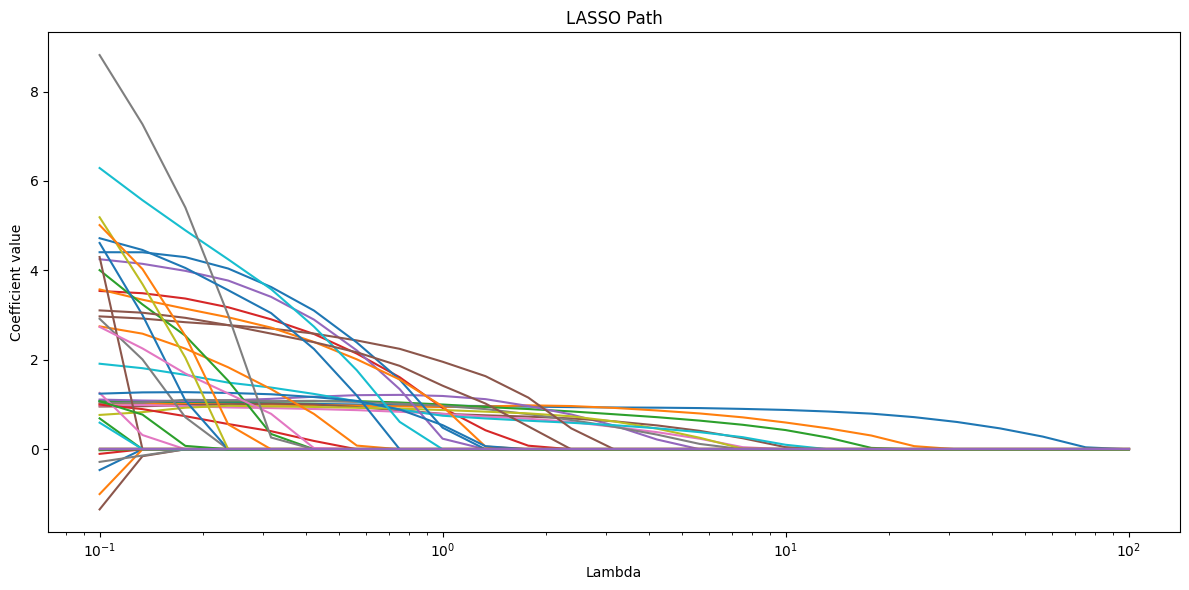

In [15]:

lasso_results.plot_lambda_path()

In [16]:
lasso_results.select_lambda_max_test_auc()

# Alternatively, manually select lambda as needed
# lasso_results.select_lambda(18)

Selected lambda index: 18
Selected lambda value: 0.5623
Corresponding test AUC: 0.8217


18

## 7. View Selected Partial Responses and Generate Nomogram

First, we visualize the contribution of each partial response selected with LASSO to the target value.

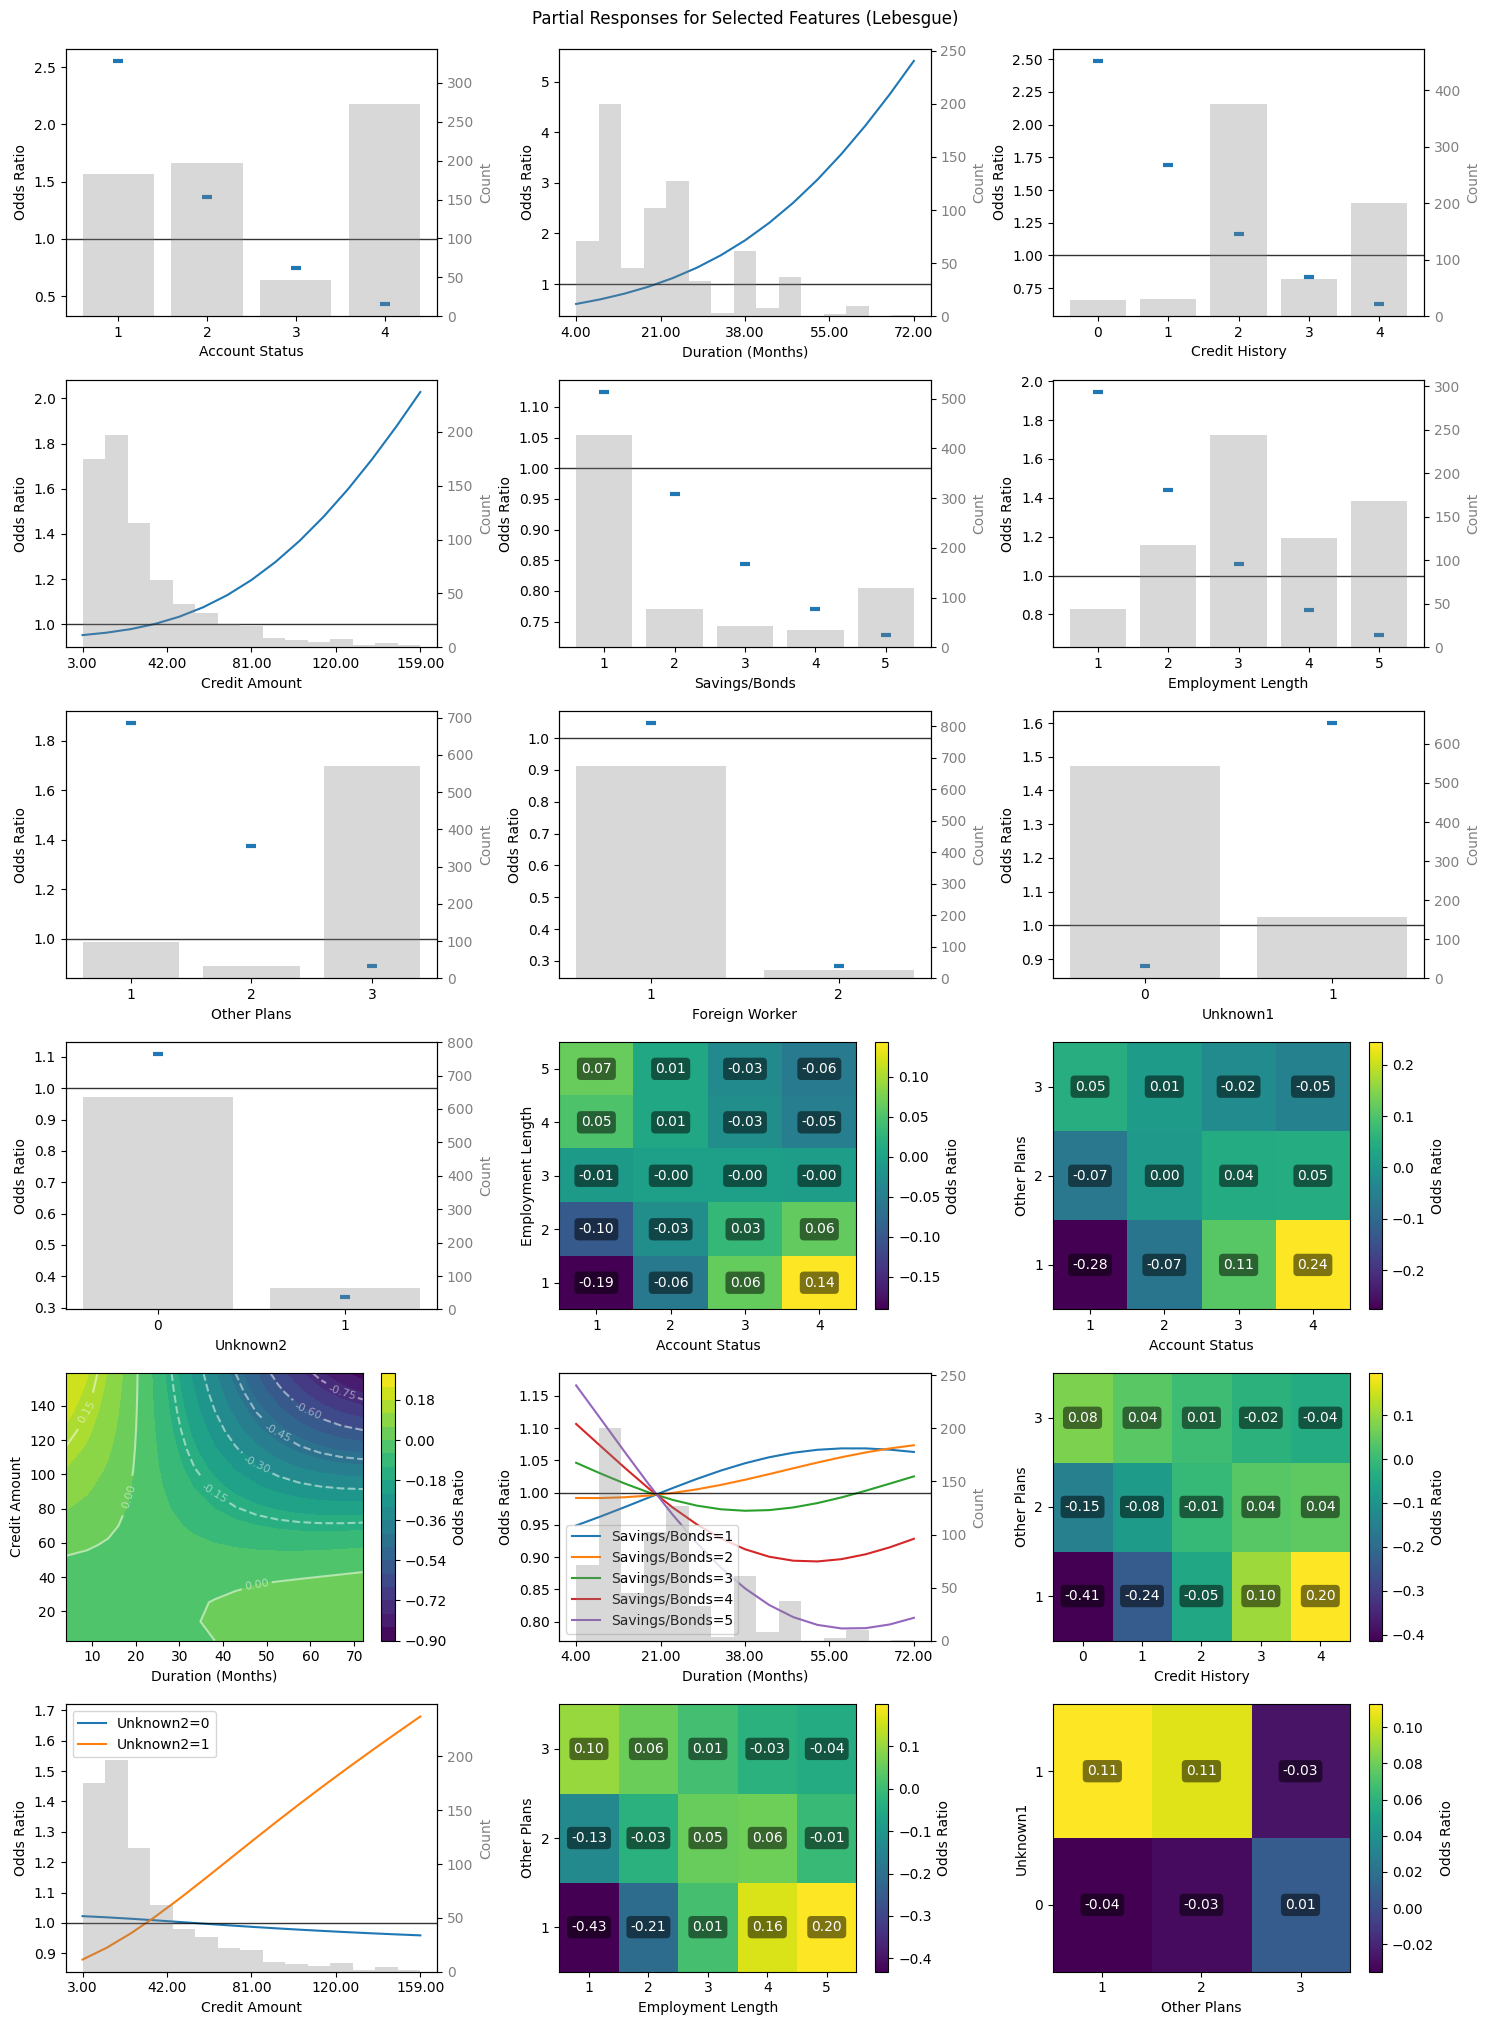

In [17]:
fig_blackbox = plot_partial_responses(
    lasso_results,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    blackbox_model,
    n_steps=15,
    sd_scale=2,
    method=partial_response_method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True,                    
    figsize=(15,20),
    show_fig=True,
    return_fig=True,
    use_odds_ratio=True
)

We can also visualize the contribution of each partial response using a nomogram. Nomograms are particularly useful in clinical settings as they provide an intuitive visual representation of a model's decision-making process.

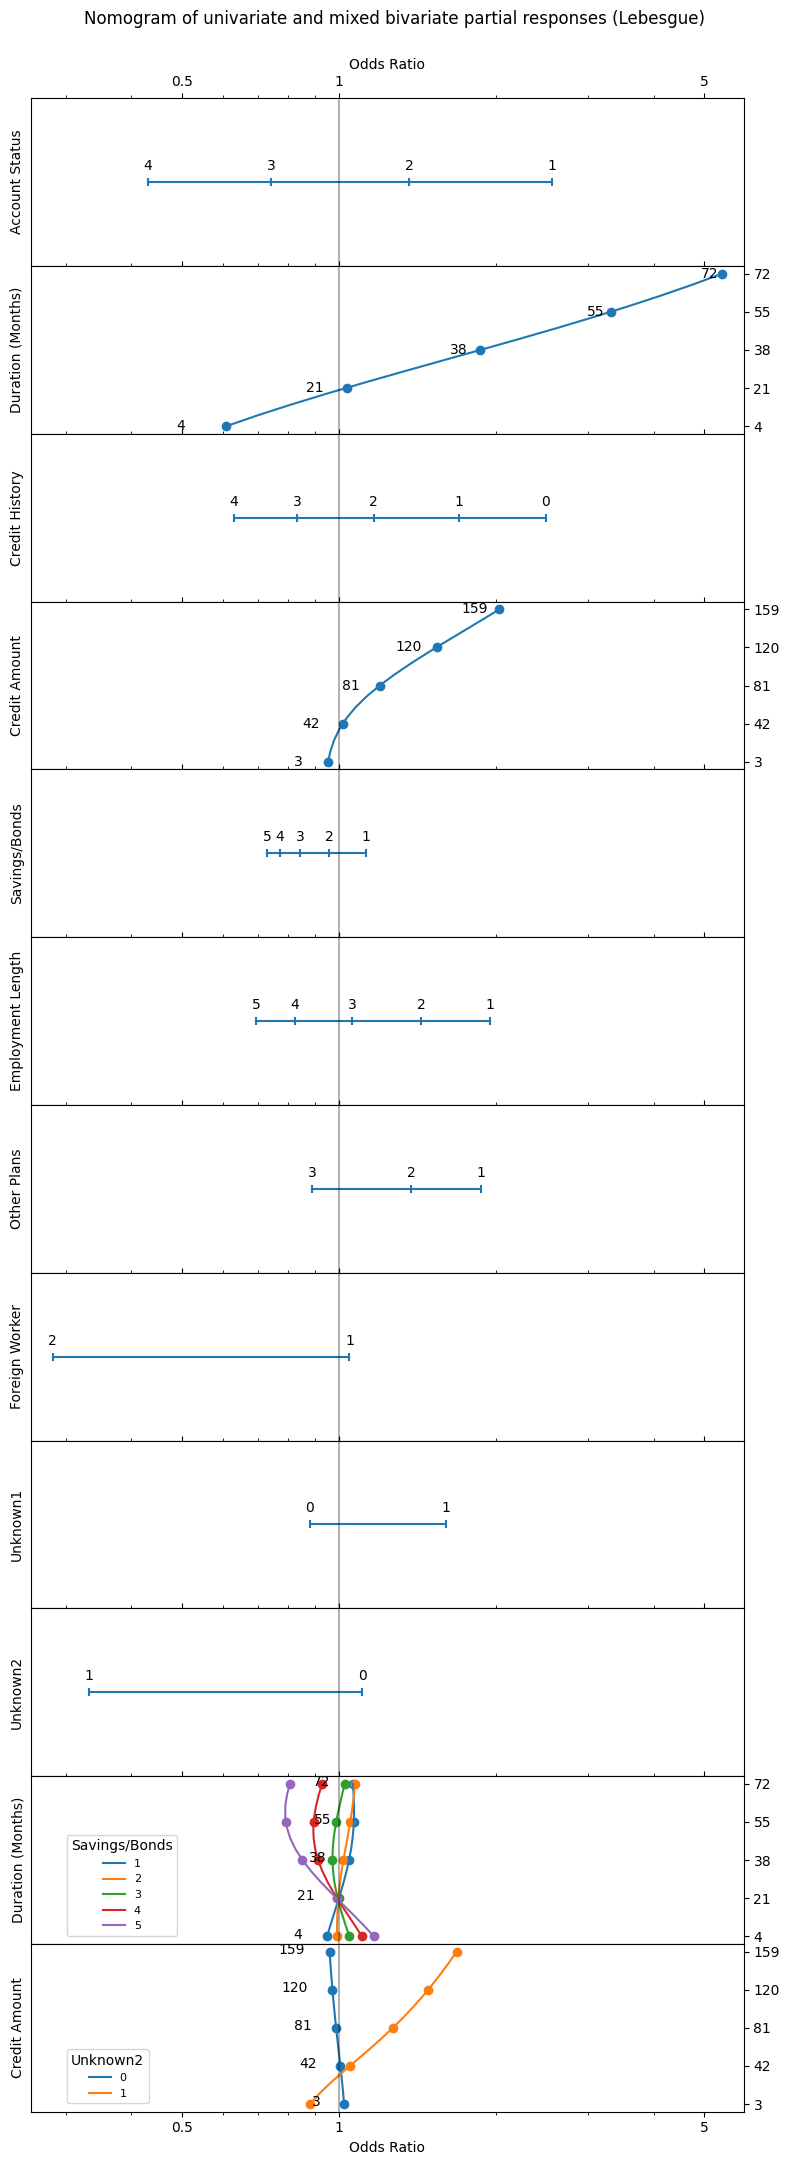

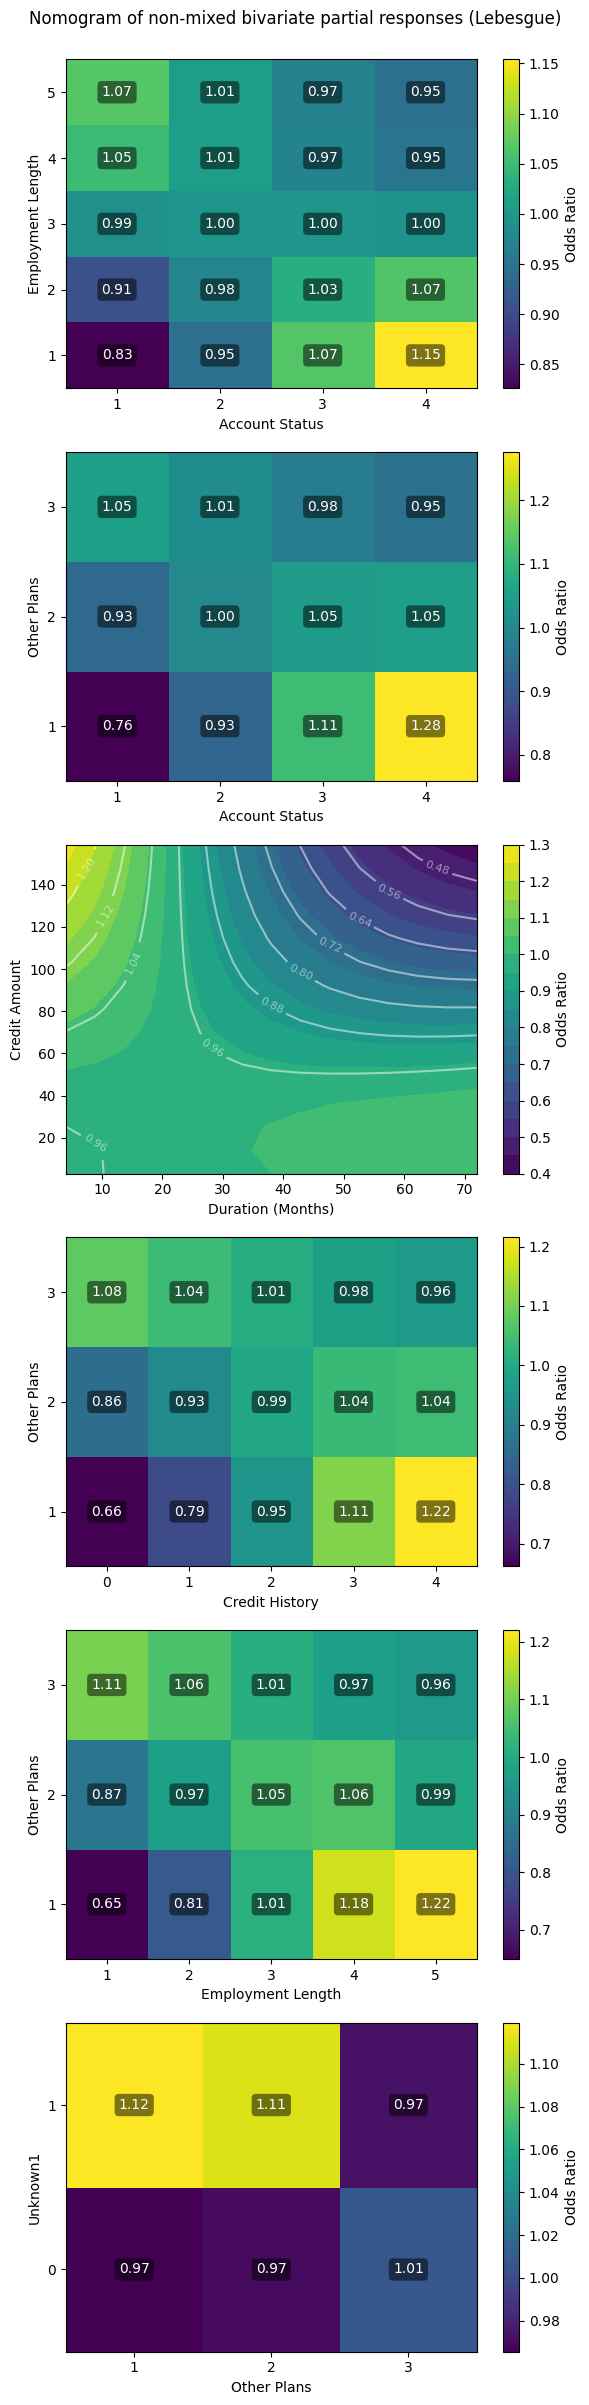

Univariate nomogram data saved to C:\Users\localuser\PRiSM\prism_github\models\nomogram_20240903_0847_univariate.csv
Bivariate nomogram data saved to C:\Users\localuser\PRiSM\prism_github\models\nomogram_20240903_0847_bivariate.csv


In [18]:
nomogram_params = {
    'n_steps' : 15,
    'sd_scale' : 2,
    'method' : partial_response_method,
    'device' : device,
    'categorical_threshold' : 15,
    'subtract_univariate' : True,
    'return_fig' : True,
    'use_odds_ratio' : True,
    'save_csv' : SAVE_METRICS,
    'csv_comment' : "MLP German CC data"
}

nomogram_results = nomogram(
    lasso_results,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    blackbox_model,
    **nomogram_params
)
nomogram_main_mlp = nomogram_results[6]
nomogram_non_mixed_mlp = nomogram_results[7]

## 8. Train Partial Response Network (PRN)

Now we train a Partial Response Network based on the selected features. The PRN is a type of neural network that incorporates the interpretability of partial responses while maintaining the predictive power of the original black box model.

From the results of the lasso feature selection, we create an input mask for the PRN. The mask is a binary matrix that determines which input features connect to which hidden nodes (subnets) in the network. This enforces the network structure based on selected features.

The PRN uses a subnet architecture, where groups of hidden nodes are dedicated to specific features or feature interactions:

- Univariate subnets: Handle individual feature effects
- Bivariate subnets: Capture interactions between two features
- The number of nodes per subnet is controlled by the subnet_nodes parameter in `train_maskedmlp` (default 5)

This gives us a resulting network structure as follows

- Input layer: Original features
- Hidden layer: Structured into subnets based on the mask
- Output layer: Single node for binary classification

The resulting PRN maintains interpretability because each subnet corresponds to a specific feature or interaction. Therefore, contribution of each feature/interaction can be analyzed separately, and the overall prediction is a sum of these interpretable components.

Selected features: ['Account Status', 'Duration (Months)', 'Credit History', 'Credit Amount', 'Savings/Bonds', 'Employment Length', 'Other Plans', 'Foreign Worker', 'Unknown1', 'Unknown2', 'Account Status : Employment Length', 'Account Status : Other Plans', 'Duration (Months) : Credit Amount', 'Duration (Months) : Savings/Bonds', 'Credit History : Other Plans', 'Credit Amount : Unknown2', 'Employment Length : Other Plans', 'Other Plans : Unknown1']


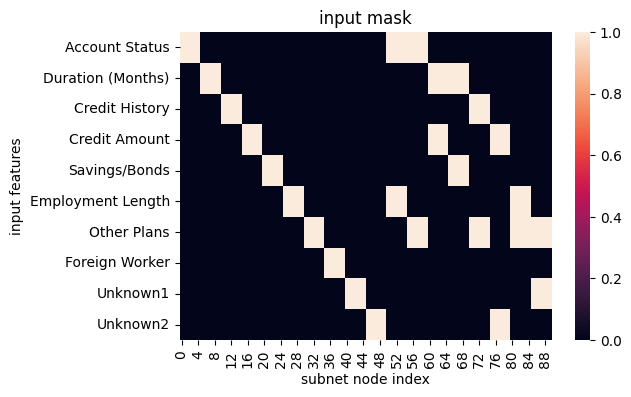

In [19]:
mask, n_features = lasso_results.get_mask()

In [20]:
prn_hyperparameters = {
    'n_hidden': n_features,
    'mask': mask,
    'subnet_nodes': 5,
    'iter': 10000,
    'lr': 0.001,
    'weight_decay': 0.00001,
    'tolerance': 0.00001,
    'patience': 100,
    'device': device,
    'seed': random_seed
}

partial_response_network = train_maskedmlp(X_train_normalized, y_train, X_test_normalized, y_test, **prn_hyperparameters)

Epoch 0, Training loss 0.6634210348129272, Test loss 0.6679077744483948
Epoch 1, Training loss 0.6700581312179565, Test loss 0.6635481715202332
Epoch 2, Training loss 0.6656980514526367, Test loss 0.6591731905937195
Epoch 3, Training loss 0.661327600479126, Test loss 0.6548444032669067
Epoch 4, Training loss 0.6570026278495789, Test loss 0.6505861282348633
Epoch 5, Training loss 0.6527457237243652, Test loss 0.6464112401008606
Epoch 6, Training loss 0.6485685706138611, Test loss 0.6423269510269165
Epoch 7, Training loss 0.6444780826568604, Test loss 0.638338029384613
Epoch 8, Training loss 0.6404786705970764, Test loss 0.634447455406189
Epoch 9, Training loss 0.636573314666748, Test loss 0.6306573748588562
Epoch 10, Training loss 0.6327640414237976, Test loss 0.6269692182540894
Epoch 11, Training loss 0.6290522813796997, Test loss 0.6233837604522705
Epoch 12, Training loss 0.6254389882087708, Test loss 0.6199013590812683
Epoch 13, Training loss 0.6219245195388794, Test loss 0.616521894


---- Model Performance Metrics PRN - train data ----
Threshold (prevalence) set to: 0.296
AUROC:		0.829 (95% CI: 0.795-0.858) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.736 (Proportion of correct predictions)
Precision:	0.536 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.792 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.639 (Harmonic mean of precision and recall)
--------------------------------------------


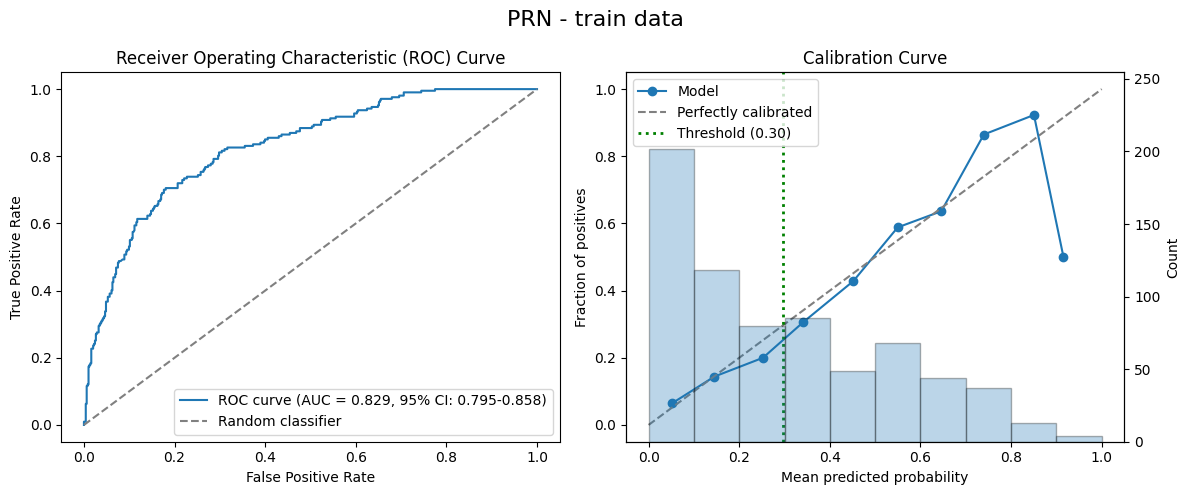


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.296

MLP:
AUROC:		0.808 (95% CI: 0.751-0.858)
Accuracy:	0.723
Precision:	0.540
Recall:		0.720
F1 Score:	0.618

PRN:
AUROC:		0.821 (95% CI: 0.768-0.869)
Accuracy:	0.717
Precision:	0.531
Recall:		0.742
F1 Score:	0.619
------------------------------------------------


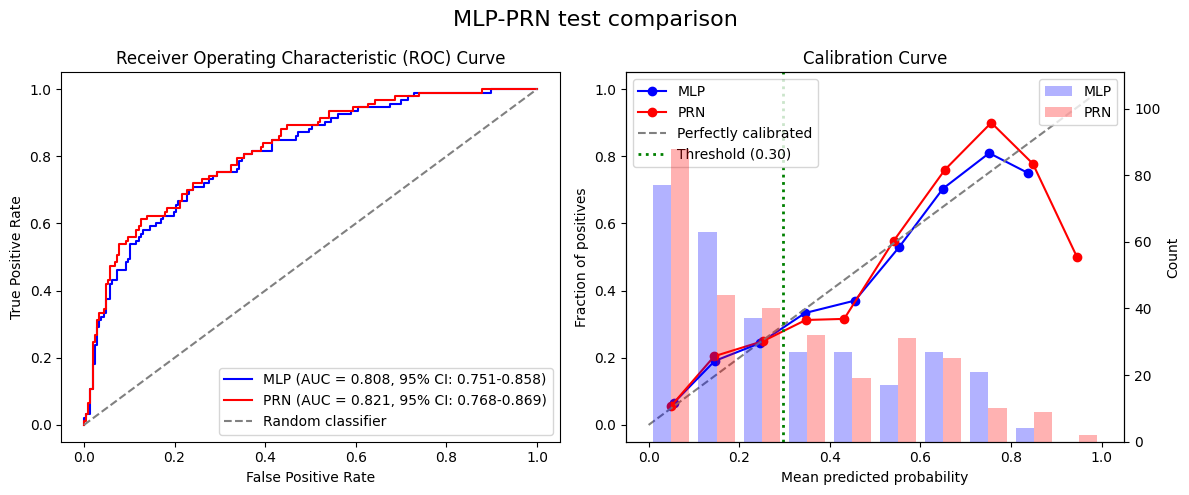

In [321]:
# Evaluate PRN on training data
y_pred_train_prn = partial_response_network.predict(X_train_tensor, device=device)

results_prn_train = evaluate_model_performance(y_train, y_pred_train_prn, y_train, title="PRN - train data")

# Evaluate PRN on test data and compare to MLP (blackbox)
y_pred_test_prn = partial_response_network.predict(X_test_tensor, device=device)

results_prn_mlp_test = compare_model_performance(y_test, y_pred_test_blackbox, y_pred_test_prn, y_train=y_train, model_names=("MLP","PRN"), title="MLP-PRN test comparison")

## 9. LASSO on PRN

We perform LASSO again, this time on the Partial Response Network to isolate the most important features and interactions.


In [322]:
partial_responses_params_prn = {
    'x_train': X_train_tensor,
    'method': partial_response_method,
    'device': device,
    'batch_size': 256,
    'max_workers': max_workers
}

partial_responses_train_prn = partial_responses(X_train_tensor, partial_response_network, **partial_responses_params_prn)
partial_responses_test_prn = partial_responses(X_test_tensor, partial_response_network, **partial_responses_params_prn)

Main compute device: cuda
Max threads: 1
Batch size: 256
Univariate 0,	(cuda)
Univariate 1,	(cuda)
Univariate 2,	(cuda)
Univariate 3,	(cuda)
Univariate 4,	(cuda)
Univariate 5,	(cuda)
Univariate 6,	(cuda)
Univariate 7,	(cuda)
Univariate 8,	(cuda)
Univariate 9,	(cuda)
Bivariate 0,1,	(cuda)
Bivariate 0,2,	(cuda)
Bivariate 0,3,	(cuda)
Bivariate 0,4,	(cuda)
Bivariate 0,5,	(cuda)
Bivariate 0,6,	(cuda)
Bivariate 0,7,	(cuda)
Bivariate 0,8,	(cuda)
Bivariate 0,9,	(cuda)
Bivariate 1,2,	(cuda)
Bivariate 1,3,	(cuda)
Bivariate 1,4,	(cuda)
Bivariate 1,5,	(cuda)
Bivariate 1,6,	(cuda)
Bivariate 1,7,	(cuda)
Bivariate 1,8,	(cuda)
Bivariate 1,9,	(cuda)
Bivariate 2,3,	(cuda)
Bivariate 2,4,	(cuda)
Bivariate 2,5,	(cuda)
Bivariate 2,6,	(cuda)
Bivariate 2,7,	(cuda)
Bivariate 2,8,	(cuda)
Bivariate 2,9,	(cuda)
Bivariate 3,4,	(cuda)
Bivariate 3,5,	(cuda)
Bivariate 3,6,	(cuda)
Bivariate 3,7,	(cuda)
Bivariate 3,8,	(cuda)
Bivariate 3,9,	(cuda)
Bivariate 4,5,	(cuda)
Bivariate 4,6,	(cuda)
Bivariate 4,7,	(cuda)
Bivaria

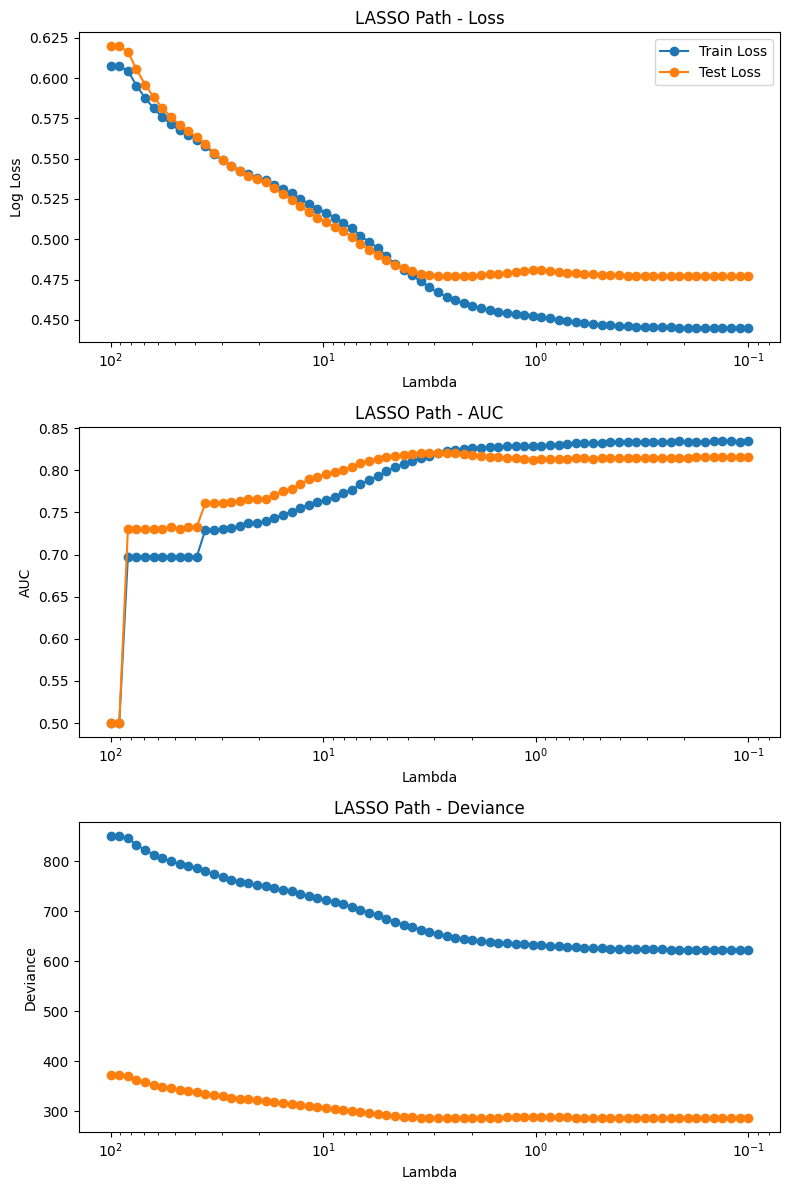

All fits converged successfully.


In [323]:
lasso_results_prn = lasso(
    partial_responses_train_prn, 
    partial_responses_test_prn, 
    y_train, 
    y_test, 
    feature_names=feature_names,
    nlambda=75, 
    min_lambda=0.1,
    max_lambda=100,
    batch_size=2,
    seed=random_seed
)

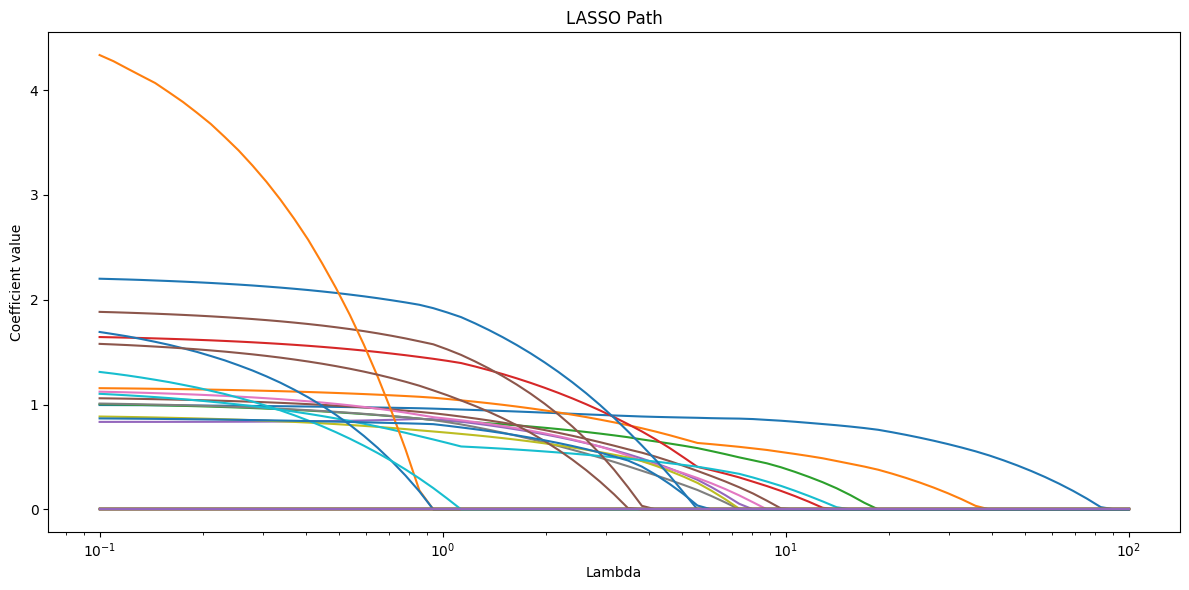

In [331]:
lasso_results_prn.plot_lambda_path()

In [332]:
lasso_results_prn.select_lambda_max_test_auc()

# Alternatively, manually select lambda as needed
# lasso_results_prn.select_lambda(38)

Selected lambda index: 38
Selected lambda value: 2.8804
Corresponding test AUC: 0.8210


38

## 10. Generate Final Nomogram

Finally, we generate a nomogram for our PRN, based on the features selected with LASSO. The nomogram provides a visual tool that can be used to understand the model's decisions.

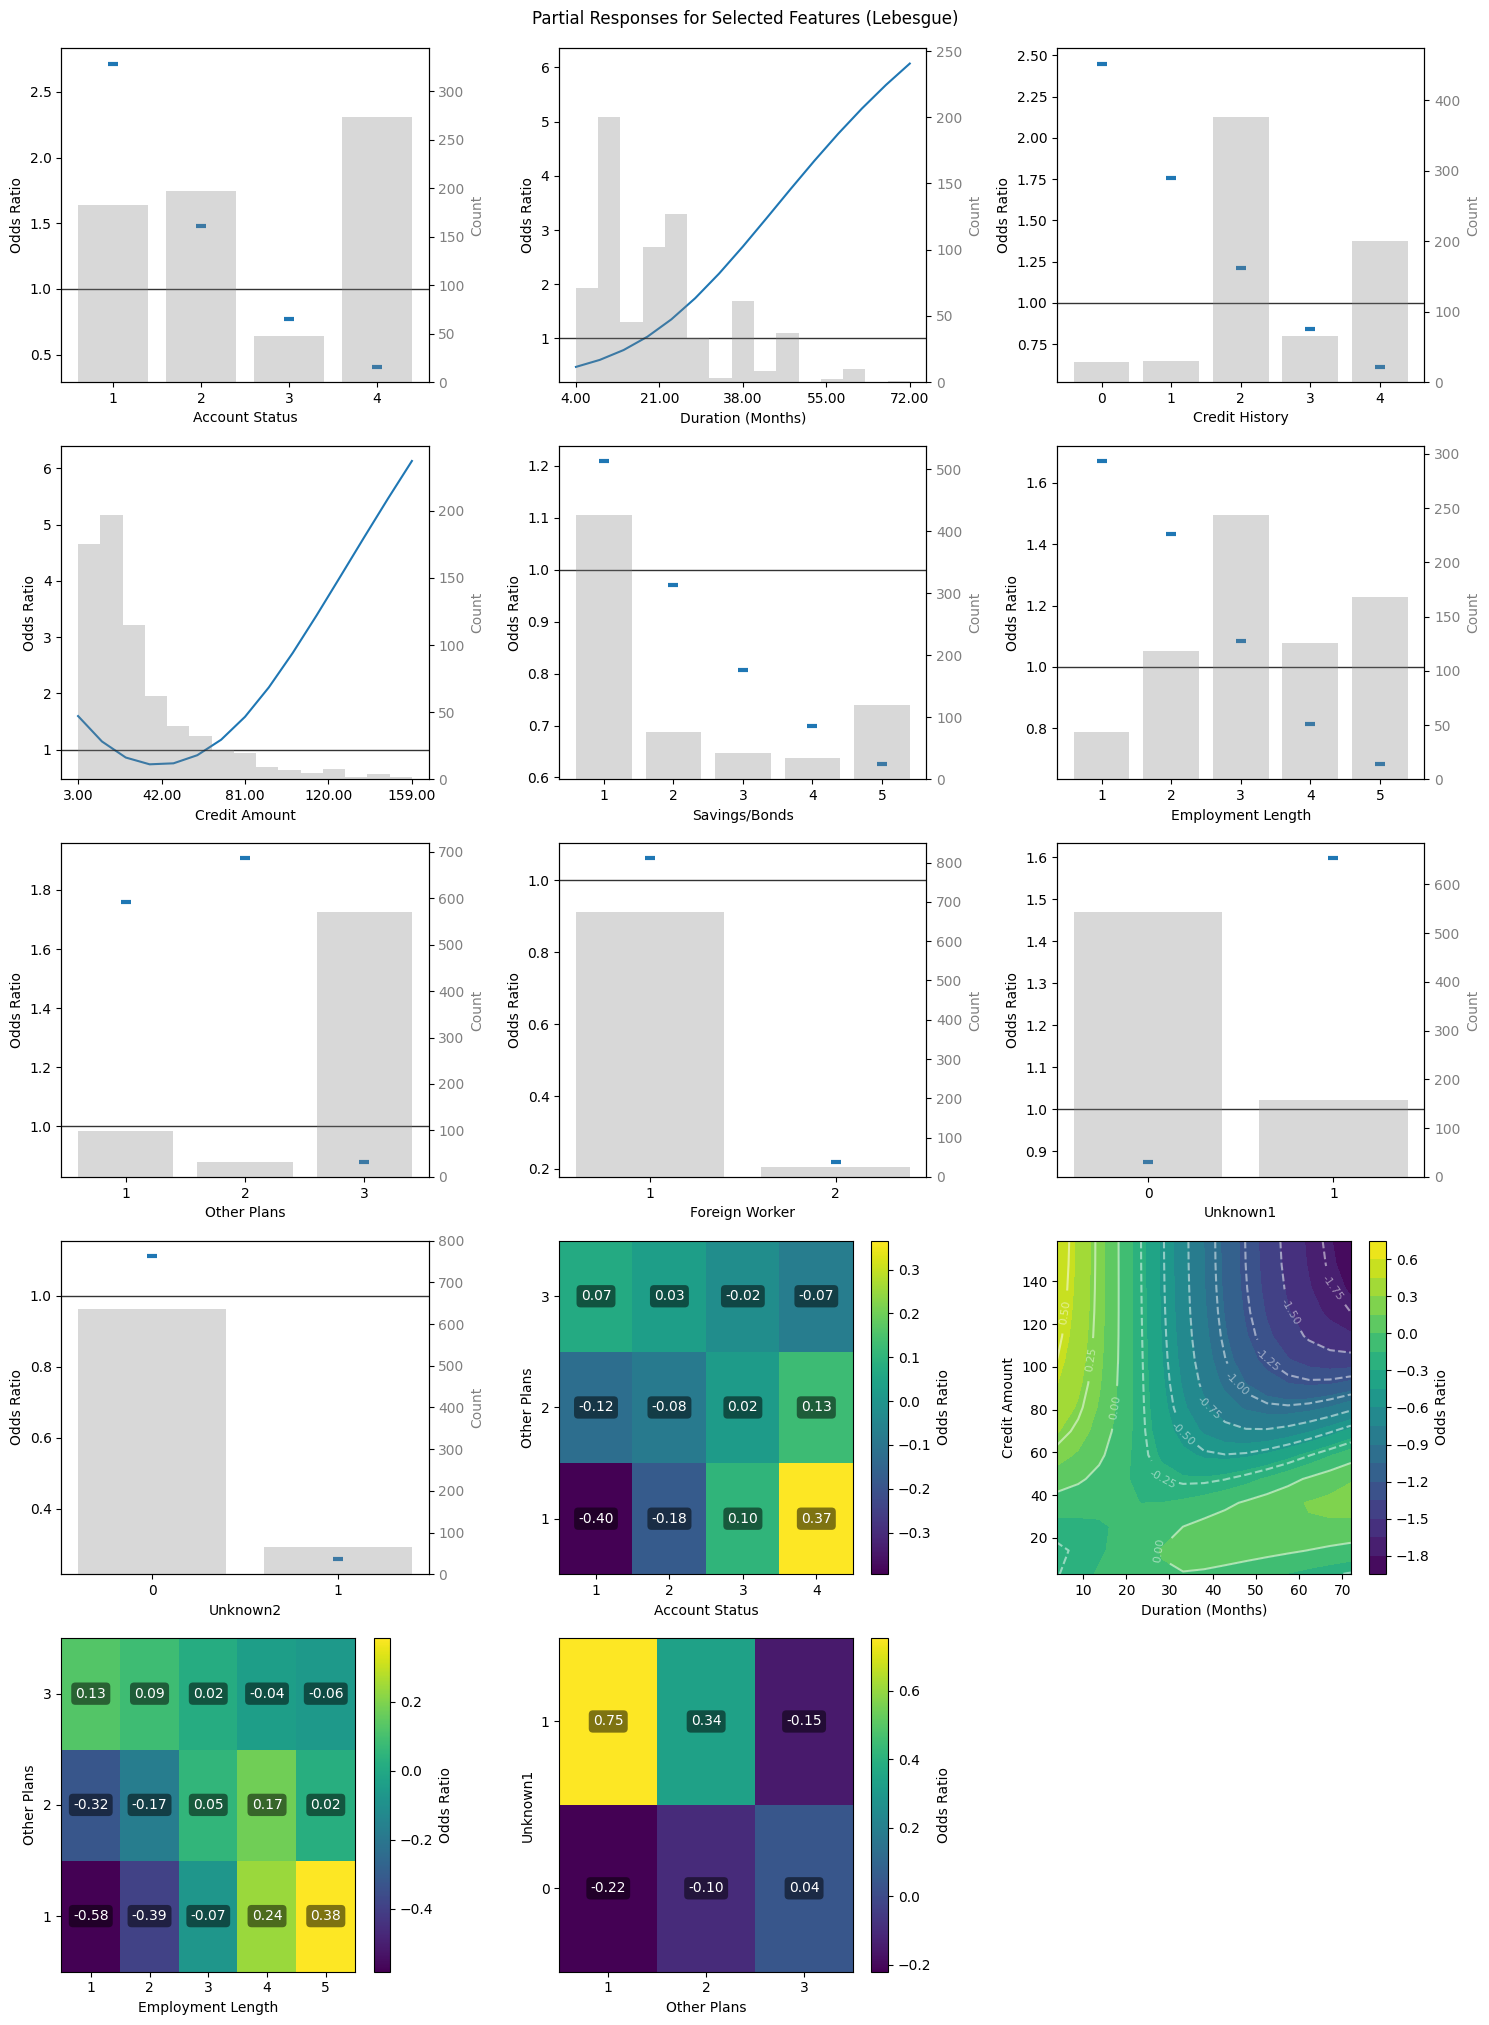

In [325]:
fig_prn = plot_partial_responses(
    lasso_results_prn,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    partial_response_network,
    n_steps=15,
    sd_scale=2,
    method=partial_response_method,
    device=device,
    categorical_threshold=15,
    subtract_univariate=True,
    figsize=(15,20),
    show_fig=True,
    return_fig=True,
    use_odds_ratio=True
)

In [326]:
%%capture
# ^ Supress nomogram plot output, will display side-by-side instead

nomogram_params_prn = {
    'n_steps' : 15,
    'sd_scale' : 2,
    'method' : partial_response_method,
    'device' : device,
    'categorical_threshold' : 15,
    'subtract_univariate' : True,
    'show_fig' : False,
    'return_fig' : True,
    'use_odds_ratio' : True,
    'save_csv' : SAVE_METRICS,
    'csv_comment' : "PRN German CC data"
}

nomogram_results_prn = nomogram(
    lasso_results_prn,
    X_train_tensor,
    X_train.median().values,
    X_train.std().values,
    partial_response_network,
    **nomogram_params_prn
)

nomogram_main_prn = nomogram_results_prn[6]
nomogram_non_mixed_prn = nomogram_results_prn[7]

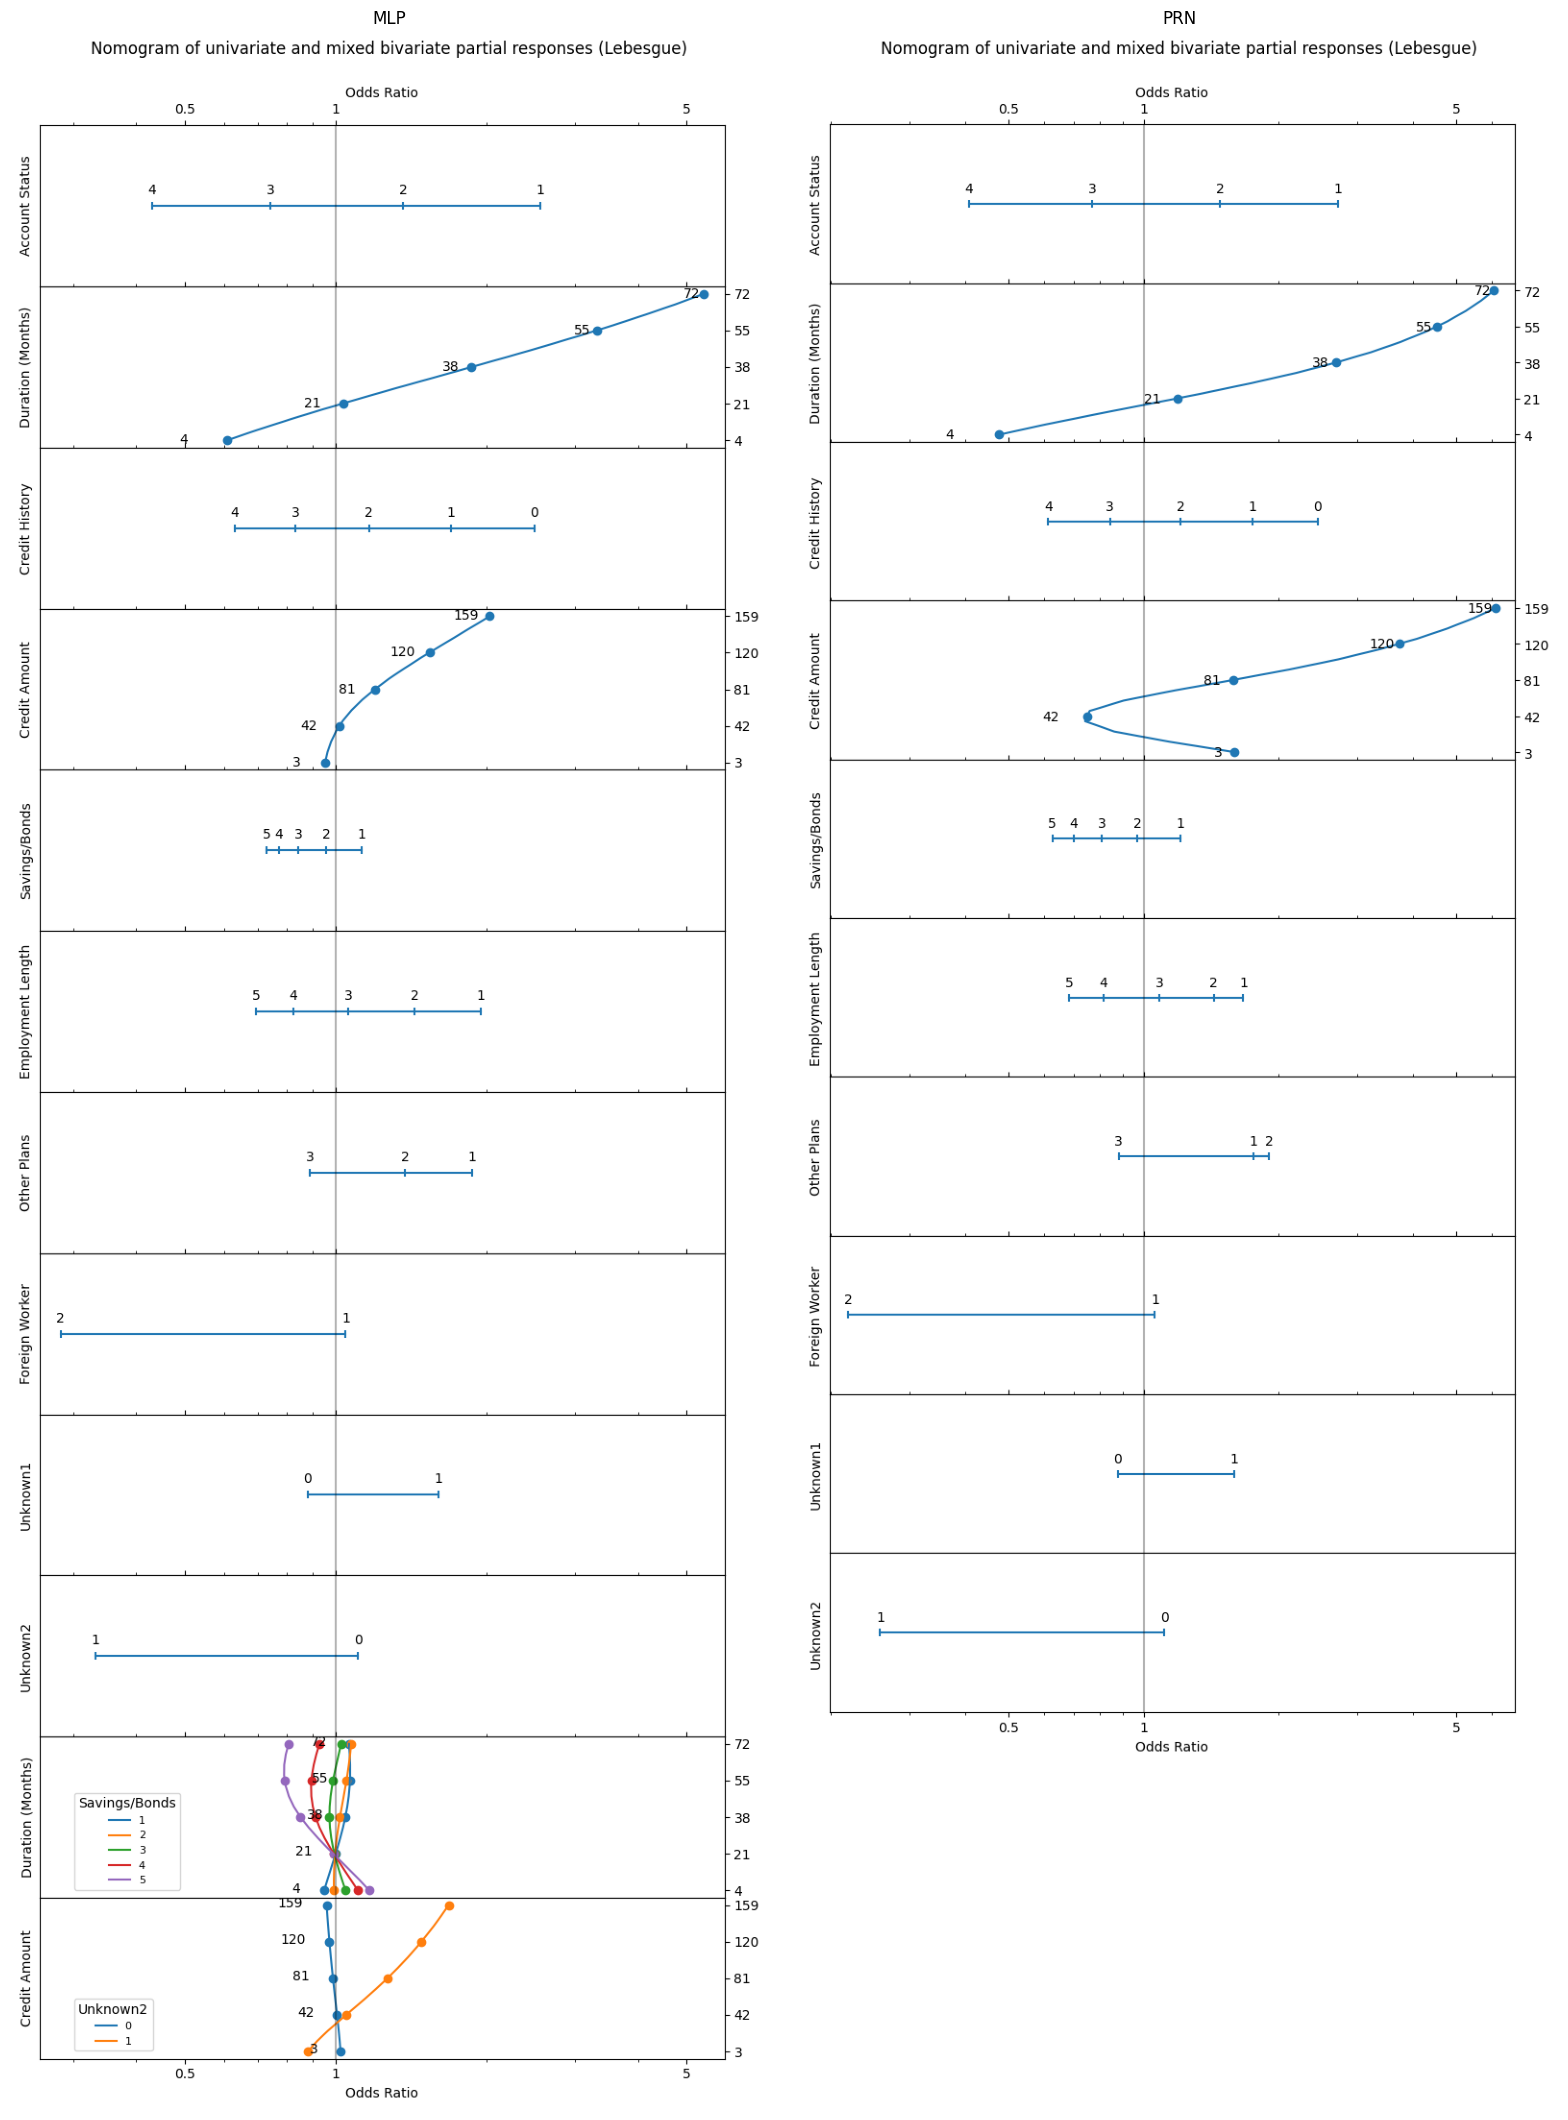

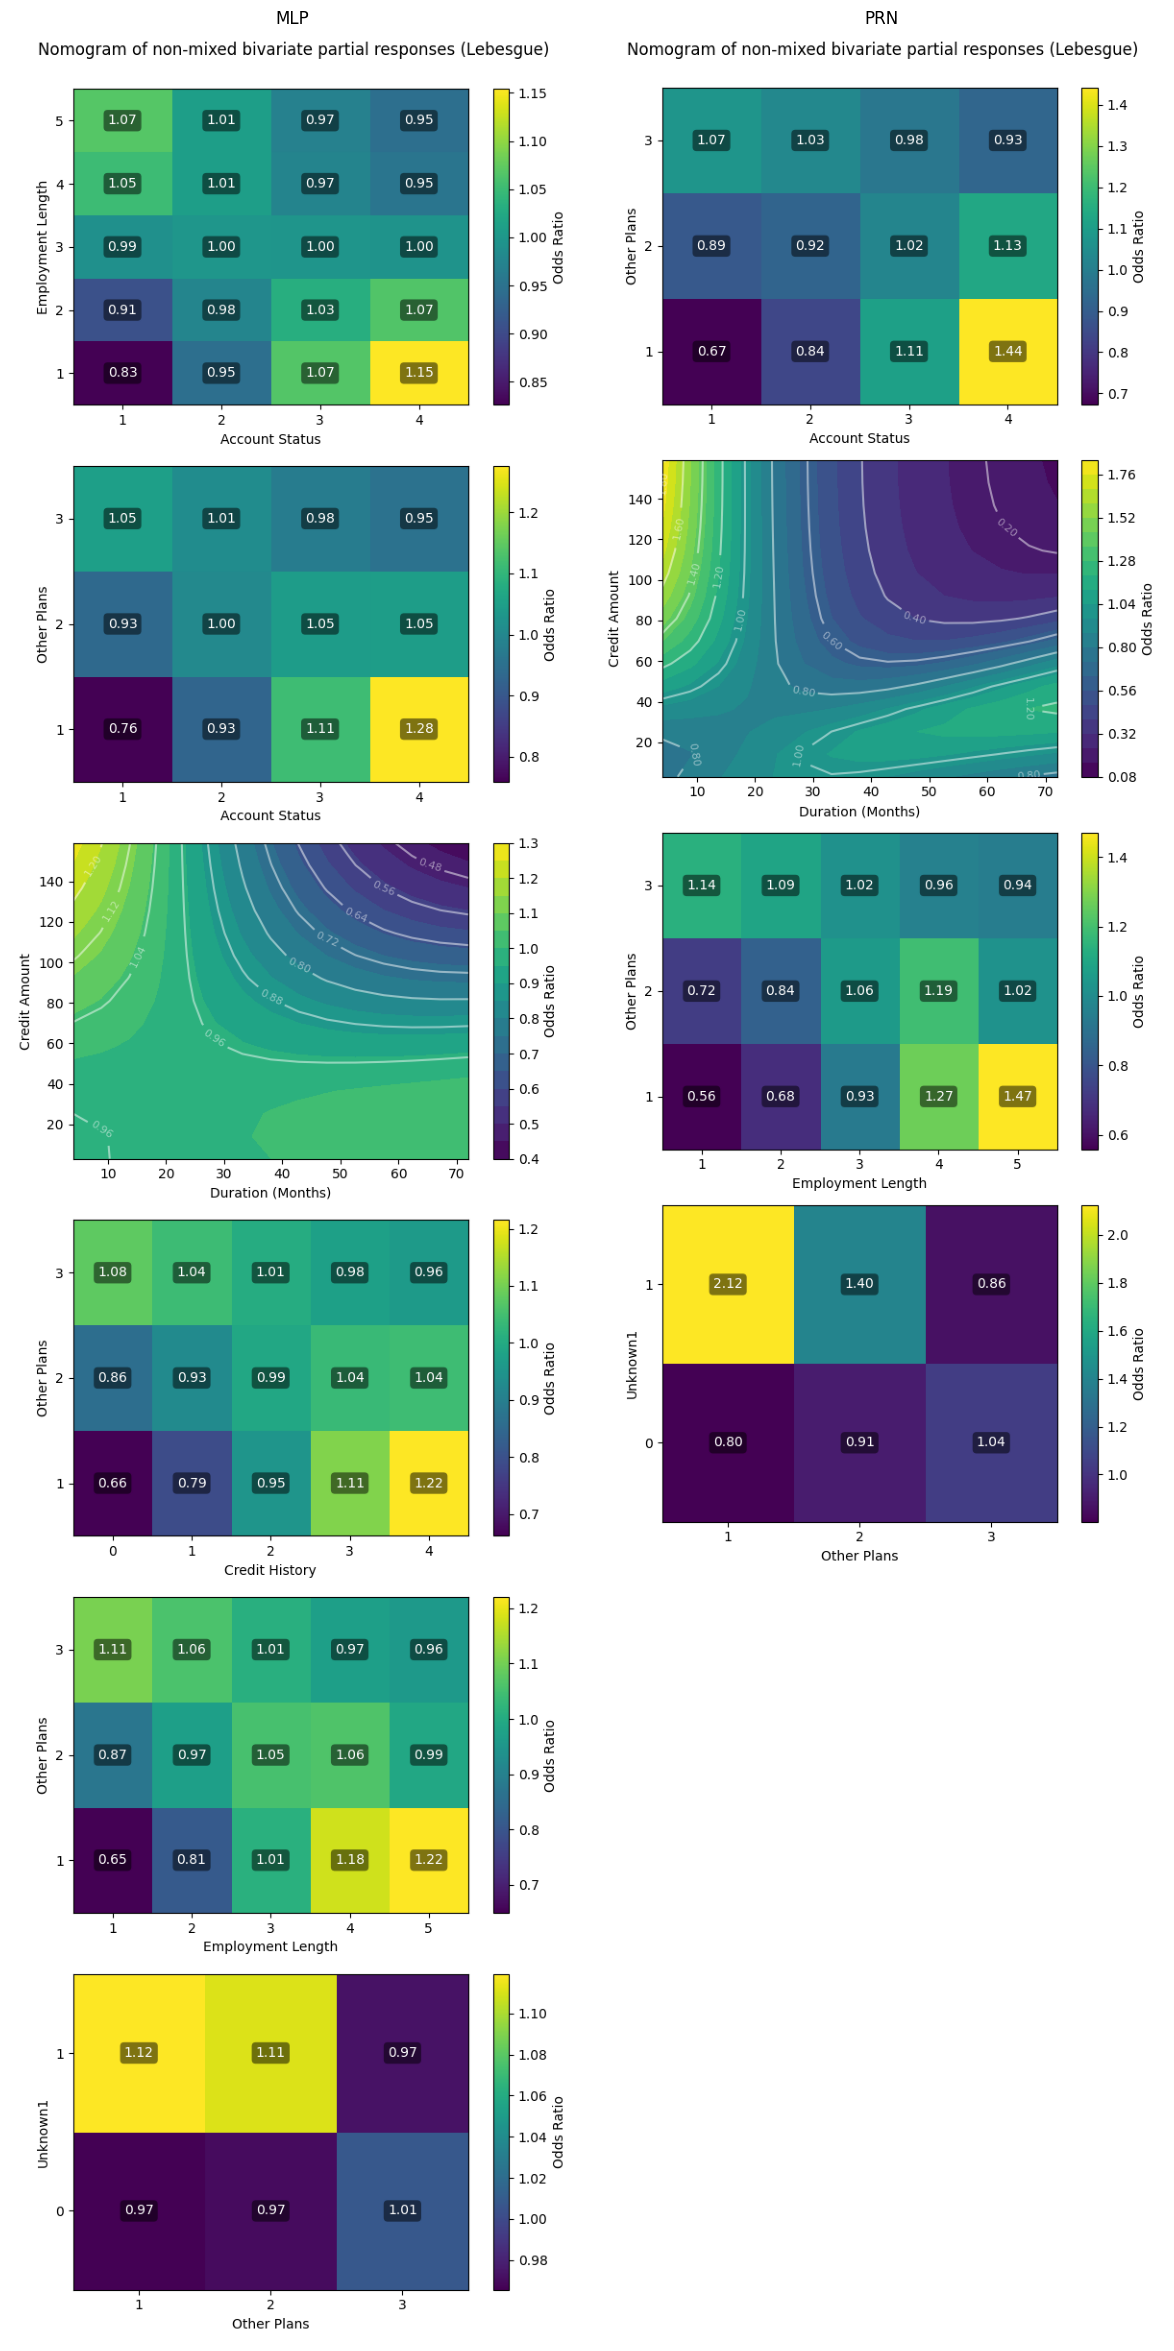

In [327]:
display_nomograms_side_by_side(nomogram_main_mlp, nomogram_non_mixed_mlp,
                               nomogram_main_prn, nomogram_non_mixed_prn)

## 11. Evaluate PRN-LASSO Model

Finally, we evaluate the simplified model (multivariate logisitic regression with LASSO regularization) trained on the partial responses of the PRN, based on the selected lambda.

This notebook demonstrates the PRiSM method, transforming a black box model into an interpretable one without sacrificing predictive performance. This approach is particularly valuable when understanding the model's decision-making process is crucial for building trust and gaining insights.

The final PRN-LASSO model provides both high predictive accuracy and interpretability, allowing us to understand how different features contribute to the predictions.

In [328]:
prn_lasso = lasso_results_prn.get_selected_model()

Logistic regression model for Lambda index 38 (2.88) selected.



---- Model Performance Metrics PRN LASSO - train data ----
Threshold (prevalence) set to: 0.296
AUROC:		0.820 (95% CI: 0.788-0.854) (Area Under the Receiver Operating Characteristic curve)
Accuracy:	0.721 (Proportion of correct predictions)
Precision:	0.519 (Proportion of true positives among positive predictions, aka PPV)
Recall:		0.802 (Proportion of true positives among actual positives, aka sensitivity)
F1 Score:	0.630 (Harmonic mean of precision and recall)
--------------------------------------------


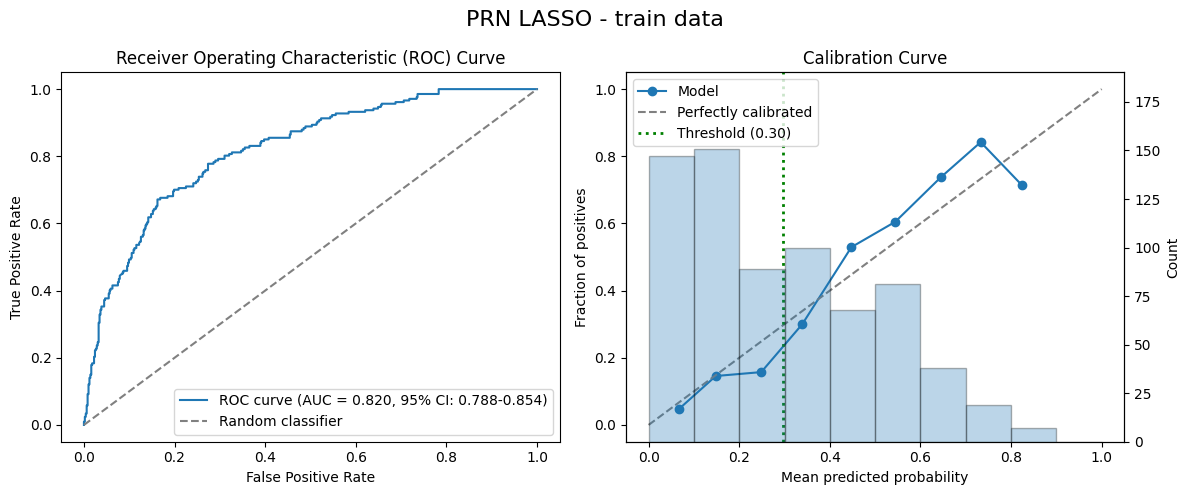


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.296

PRN:
AUROC:		0.821 (95% CI: 0.768-0.869)
Accuracy:	0.717
Precision:	0.531
Recall:		0.742
F1 Score:	0.619

PRN LASSO:
AUROC:		0.821 (95% CI: 0.770-0.869)
Accuracy:	0.717
Precision:	0.529
Recall:		0.796
F1 Score:	0.635
------------------------------------------------


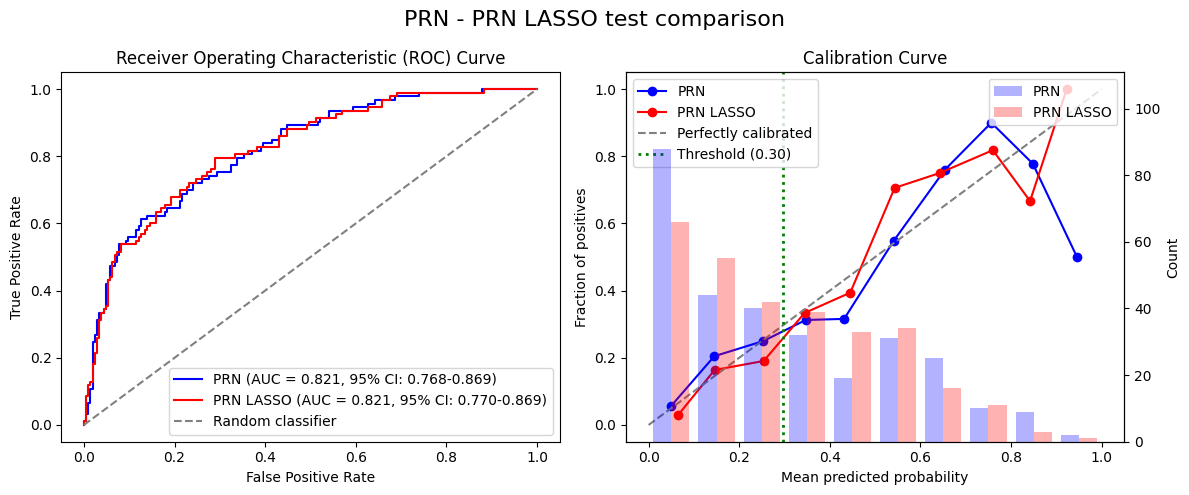


-------- Model Performance Comparison --------
Threshold (prevalence) set to: 0.296

MLP:
AUROC:		0.808 (95% CI: 0.755-0.858)
Accuracy:	0.723
Precision:	0.540
Recall:		0.720
F1 Score:	0.618

PRN LASSO:
AUROC:		0.821 (95% CI: 0.765-0.868)
Accuracy:	0.717
Precision:	0.529
Recall:		0.796
F1 Score:	0.635
------------------------------------------------


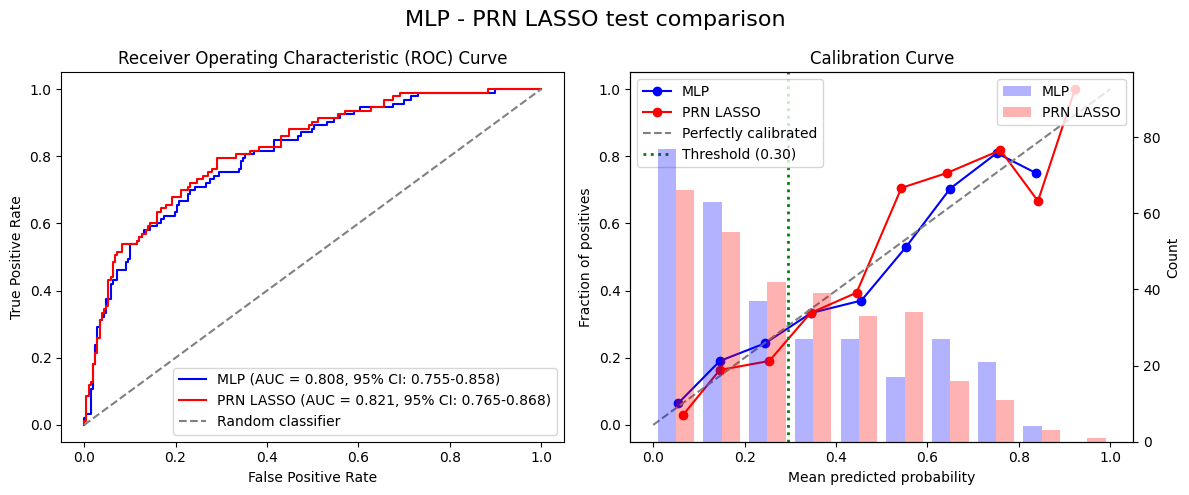

In [329]:
# Evaluate PRN-LASSO on training data
y_pred_train_prn_lasso = prn_lasso.predict_proba(partial_responses_train_prn)[:, 1]

results_prn_lasso_train = evaluate_model_performance(y_train, y_pred_train_prn_lasso, y_train, title="PRN LASSO - train data")

# Evaluate PRN-LASSO on test data and compare to PRN
y_pred_test_prn_lasso = prn_lasso.predict_proba(partial_responses_test_prn)[:, 1]

results_prn_prn_lasso_test = compare_model_performance(y_test, y_pred_test_prn, y_pred_test_prn_lasso, y_train=y_train, model_names=("PRN","PRN LASSO"), title="PRN - PRN LASSO test comparison")

# Compare PRN-LASSO and original MLP (blackbox) model
results_prn_mlp_test = compare_model_performance(y_test, y_pred_test_blackbox, y_pred_test_prn_lasso, y_train=y_train, model_names=("MLP","PRN LASSO"), title="MLP - PRN LASSO test comparison")